In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

In [2]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("huNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)

    
v2s=[]
v2strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 380:404"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v2s.append(sub)        
    v2strings.append(sub2)
    
    
    
v3s=[]
v3strings=[]
combinedLoopString="resid 415:430"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v3s.append(sub)        
    v3strings.append(sub2)
    
    
    
v123s=[]
v123strings=[]
combinedLoopString="resid 324:349 or resid 380:40 or resid 415:430"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v123s.append(sub)        
    v123strings.append(sub2)    
    
    
        
        
        
complexRef = mda.Universe("../complex/1/3_npt/protein_cluster_center_ff.gro")
hivseq = complexRef.select_atoms("resid 1:232").residues.resnames[:231]


complexUs=[]
for j in range(5):
    tu = mda.Universe("../complex/"+str(j+1)+"/3_npt/protein_cluster_center_ff.gro","../complex/"+str(j+1)+"/3_npt/protein_cluster_center_skip100.xtc")

    complexUs.append(tu)
    
complexTRIM=[]
complexTRIM_strings=[]
for i in range(len(complexUs)):
    complexTRIM.append(complexUs[i].select_atoms("protein and resid 289:20000"))
    complexTRIM_strings.append("protein and resid 289:20000")

In [3]:
# Ok let's do PCA
def getPairwiseDists(systems,datasets,selection_strings,stride = 10,EQPOINT=250):
    
    alldists=[]
    for i in range(len(datasets)):
        subdists=[]
        for j in range(len(datasets[i])):
            distances=[]
            for k in range(int(EQPOINT/stride),int(len(systems[i][j].trajectory)/stride)):
                systems[i][j].trajectory[k*stride]
                distances.append(MDAnalysis.analysis.distances.self_distance_array(datasets[i][j].select_atoms("name CA").positions))
            subdists.append(distances)
        alldists.append(subdists)
    return alldists


In [4]:

dists = getPairwiseDists(systems,v1s,v1strings,stride = 1,EQPOINT=EQPOINT)




In [5]:
#save("allpcadists-V2-CApairwise.npy",dists)
#dists=load("allpcadists-V1-CApairwise.npy")

shaped_dists=[]
pca_colours = []
for i in range(len(dists)):
    for j in range(len(dists[i])):
        for k in range(len(dists[i][j])):
            shaped_dists.append(dists[i][j][k])
            pca_colours.append(colourScheme[i])
            
            

Z=sklearn.preprocessing.StandardScaler().fit_transform(shaped_dists)

myPCA=sklearn.decomposition.PCA(n_components=2)
myfit=myPCA.fit(Z)
pcaX=myPCA.transform(Z)
pcaPoints= pcaX.T

In [6]:
#Create a scaler
scaler = sklearn.preprocessing.StandardScaler()
# Fit scaler with the distances from the structures
scaler.fit(shaped_dists)
# get the mean and scale of this transformation
scale_final = scaler.scale_
mean_final = scaler.mean_


scaled_dists = (copy(dists) - mean_final)/scale_final
transformed_dists = []
for i in range(len(scaled_dists)):
    sub=[]
    for j in range(len(scaled_dists[i])):
        sub.append(myPCA.transform(scaled_dists[i][j]))
        
    transformed_dists.append(sub)

In [7]:
mean_final

array([ 3.88061333,  6.33406275,  7.93125834, 10.23976914, 12.11539432,
       14.26700691, 15.98796565, 17.53273867, 18.75320947, 19.00237285,
       19.07662372, 18.82638371, 18.50376414, 18.01854223, 17.09785557,
       16.21069185, 15.50267636, 14.4394403 , 13.48169307, 12.2776388 ,
       12.67102351,  3.83997117,  6.16094116,  8.5409029 , 10.70030465,
       12.98468303, 14.8082748 , 16.37190252, 17.63572148, 17.89624169,
       17.98806669, 17.65246711, 17.23118516, 16.69966232, 15.87287034,
       15.03044171, 14.4824253 , 13.65750917, 13.06987239, 12.34446324,
       13.39169294,  3.84022473,  6.29305964,  8.62785981, 10.9674222 ,
       12.99810421, 14.72926092, 16.12710132, 16.4861235 , 16.66266148,
       16.38332201, 16.15535896, 15.78810532, 15.20055797, 14.48327417,
       14.1588147 , 13.61623789, 13.45516001, 13.0335656 , 14.46771372,
        3.8373046 ,  6.35561115,  8.76102036, 10.97695207, 12.89694983,
       14.39510818, 14.86038368, 15.16092486, 15.08350567, 15.24

Text(0.5, 0, 'PC1')

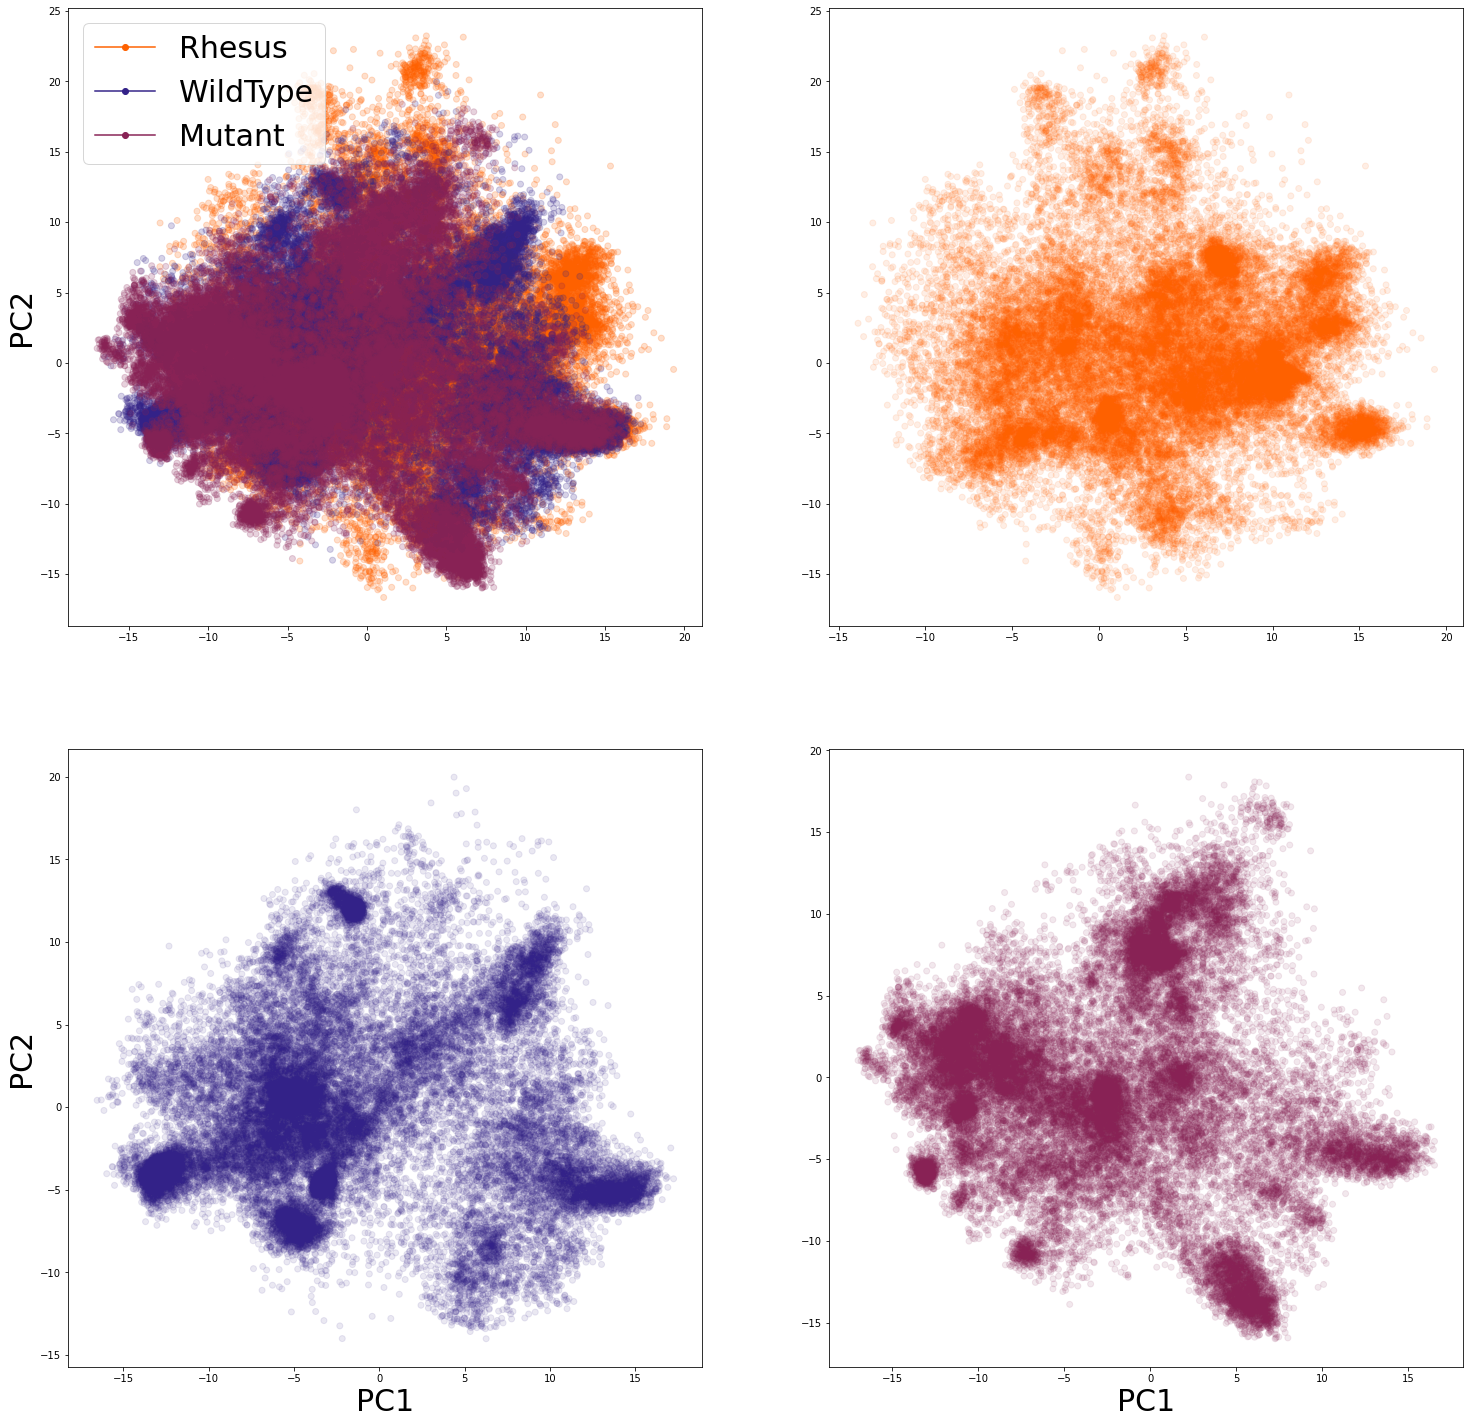

In [8]:
#style.use("ggplot")
figure(figsize = (25,25))
#for i in range(len(pcaPoints.T)):
#    scatter(pcaPoints.T[i][0],pcaPoints.T[i][1],color = pca_colours[i],alpha = 0.1)#,color = mycolors[i])#,label = structureList[i][3:])

subplot(2,2,1)
scatter(*pcaPoints,color = pca_colours,alpha = 0.2)
legend_elements = [Line2D([0], [0], marker='o', color=colourScheme[0], label="Rhesus"),
                       Line2D([0], [0], marker='o', color=colourScheme[1], label="WildType"),
                       Line2D([0], [0], marker='o', color=colourScheme[2], label="Mutant")]
legend(handles = legend_elements,loc='best',fontsize = 30)
ylabel("PC2",fontsize = 30)
#ylim(-18,25)
#xlim(-18,21)
#xticks([])
#yticks([])

subplot(2,2,2)
scatter(pcaPoints[0][:int(len(pcaPoints[0])/3)],pcaPoints[1][:int(len(pcaPoints[0])/3)],color = pca_colours[:int(len(pcaPoints[0])/3)],alpha = 0.1)

#xticks([])
#yticks([])
#ylim(-18,25)
#xlim(-18,21)

subplot(2,2,3)
scatter(pcaPoints[0][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],pcaPoints[1][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],color = pca_colours[int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],alpha = 0.1)

#xticks([])
#yticks([])
#ylim(-18,25)
#xlim(-18,21)
xlabel("PC1",fontsize = 30)
ylabel("PC2",fontsize = 30)


subplot(2,2,4)
scatter(pcaPoints[0][2*int(len(pcaPoints[0])/3):],pcaPoints[1][2*int(len(pcaPoints[0])/3):],color = pca_colours[2*int(len(pcaPoints[0])/3):],alpha = 0.1)
#xticks([])
#yticks([])
#ylim(-18,25)
#xlim(-18,21)
xlabel("PC1",fontsize = 30)


In [9]:
max(pcaPoints[0])

19.32226413328419

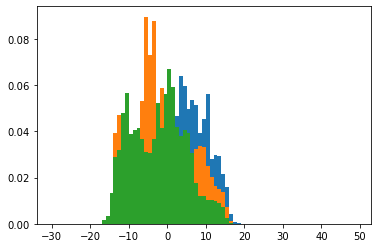

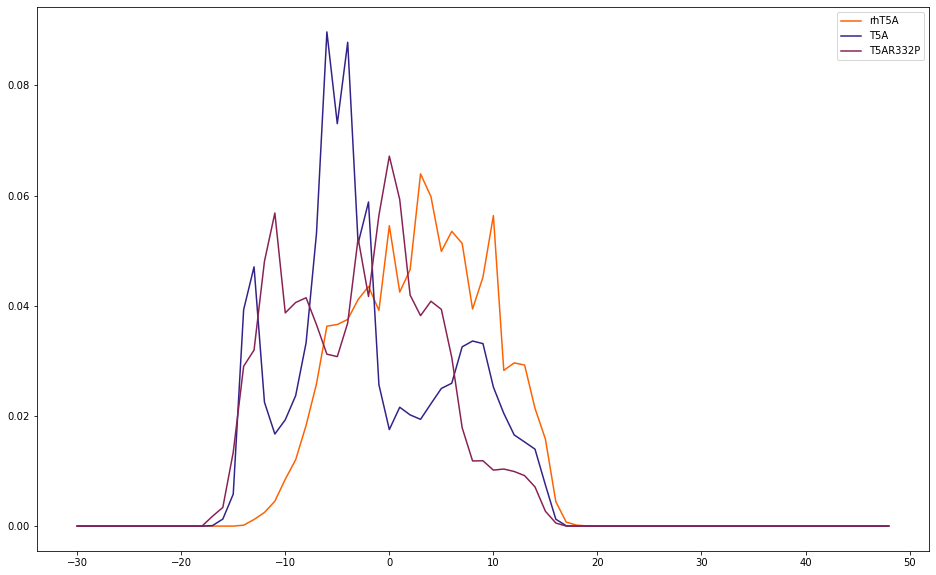

In [10]:
binrange = arange(-30,50,1)

#system_pcaPoints = pcaPoints.reshape(3,2,int(len(pcaPoints[0])/3)) # For some reason this makes things backwards
systempc1s=[]
systempc1s.append(pcaPoints[0][:int(len(pcaPoints[0])/3)])
systempc1s.append(pcaPoints[0][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)])
systempc1s.append(pcaPoints[0][2*int(len(pcaPoints[0])/3):])

    
pc1hists=[]
for i in range(len(systempc1s)):
    a = hist(systempc1s[i],bins = binrange,density = True)[0]
    pc1hists.append(a)
    
    
    
figure(figsize = (16,10))
for i in range(len(pc1hists)):
    plot(binrange[:-1],pc1hists[i],color = threeColor[i],label = system_names[i])
    
legend()





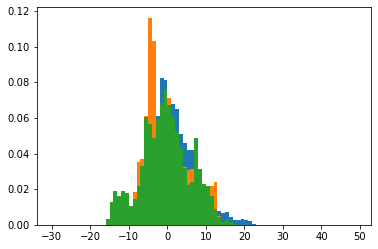

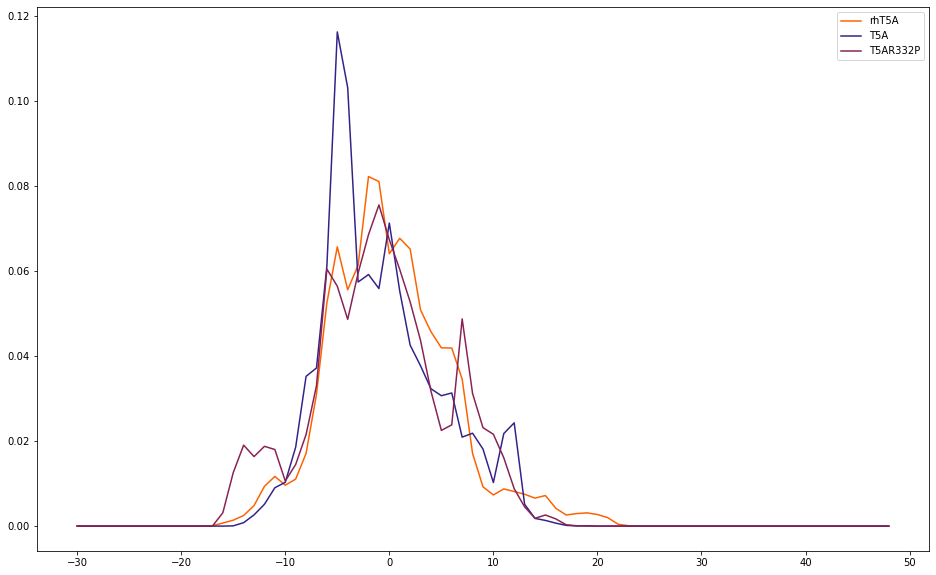

In [11]:
binrange = arange(-30,50,1)

#system_pcaPoints = pcaPoints.reshape(3,2,int(len(pcaPoints[0])/3)) # For some reason this makes things backwards
system_pc2s=[]
system_pc2s.append(pcaPoints[1][:int(len(pcaPoints[1])/3)])
system_pc2s.append(pcaPoints[1][int(len(pcaPoints[1])/3):2*int(len(pcaPoints[1])/3)])
system_pc2s.append(pcaPoints[1][2*int(len(pcaPoints[1])/3):])

    
pc2hists=[]
for i in range(len(system_pc2s)):
    a = hist(system_pc2s[i],bins = binrange,density = True)[0]
    pc2hists.append(a)
    
    
    
figure(figsize = (16,10))
for i in range(len(pc2hists)):
    plot(binrange[:-1],pc2hists[i],color = threeColor[i],label = system_names[i])
    
legend()





C:\Users\Liam\anaconda3\envs\mda2\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\Liam\anaconda3\envs\mda2\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\Liam\anaconda3\envs\mda2\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.w

Text(0.5, 49.99999999999995, 'PC1')

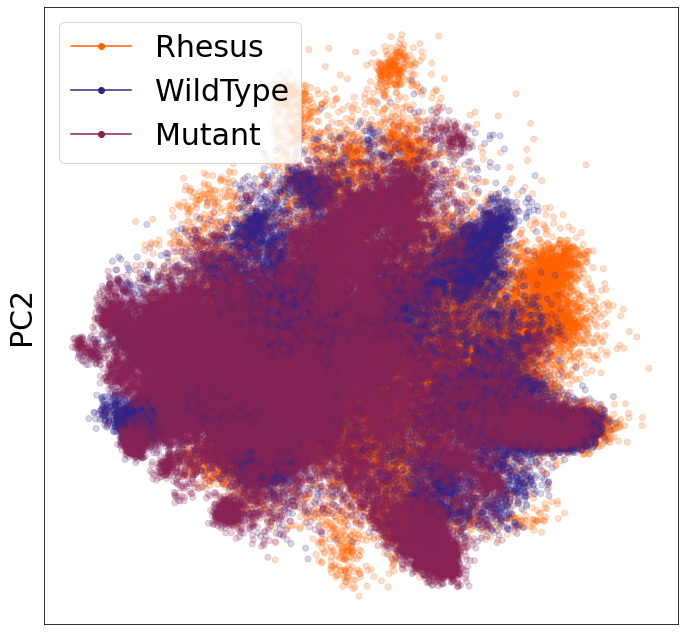

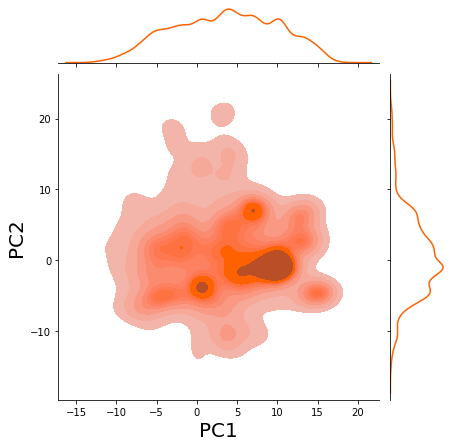

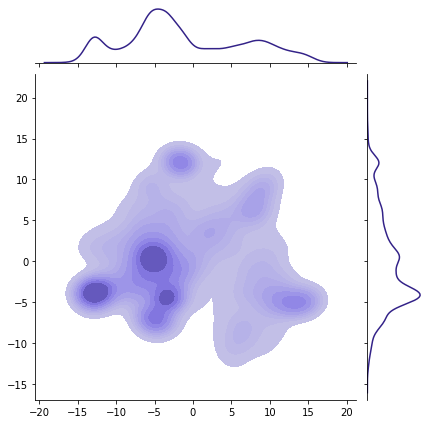

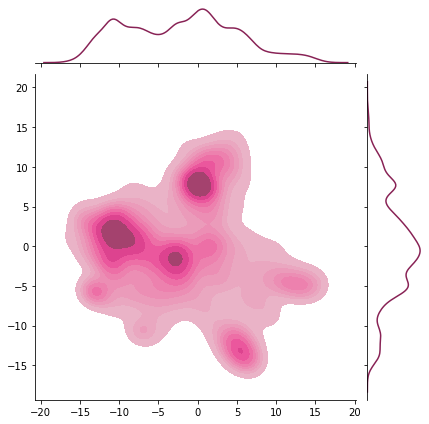

In [12]:
#style.use("ggplot")
figure(figsize = (25,25))
#for i in range(len(pcaPoints.T)):
#    scatter(pcaPoints.T[i][0],pcaPoints.T[i][1],color = pca_colours[i],alpha = 0.1)#,color = mycolors[i])#,label = structureList[i][3:])

subplot(2,2,1)
scatter(*pcaPoints,color = pca_colours,alpha = 0.2)
legend_elements = [Line2D([0], [0], marker='o', color=colourScheme[0], label="Rhesus"),
                       Line2D([0], [0], marker='o', color=colourScheme[1], label="WildType"),
                       Line2D([0], [0], marker='o', color=colourScheme[2], label="Mutant")]
legend(handles = legend_elements,loc='best',fontsize = 30)
ylabel("PC2",fontsize = 30)
#ylim(-20,45)
#xlim(-20,50)
xticks([])
yticks([])


h=sns.jointplot(pcaPoints[0][:int(len(pcaPoints[0])/3)],pcaPoints[1][:int(len(pcaPoints[0])/3)],kind = 'kde',shade = True, color=colourScheme[0])
h.set_axis_labels('PC1', 'PC2', fontsize=20)
h.set
#xticks([])
#yticks([])
#ylim(-20,45)
#xlim(-20,50)
#
sns.jointplot(pcaPoints[0][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],pcaPoints[1][int(len(pcaPoints[0])/3):2*int(len(pcaPoints[0])/3)],kind = 'kde',shade= True, color = colourScheme[1])

#xticks([])
#yticks([])
#ylim(-20,45)
#xlim(-20,50)
xlabel("PC1",fontsize = 30)
ylabel("PC2",fontsize = 30)


sns.jointplot(pcaPoints[0][2*int(len(pcaPoints[0])/3):],pcaPoints[1][2*int(len(pcaPoints[0])/3):],kind = 'kde',shade = True,color=colourScheme[2])
#xticks([])
#yticks([])
#ylim(-20,45)
#xlim(-20,50)
xlabel("PC1",fontsize = 30)


C:\Users\Liam\anaconda3\envs\mda2\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
C:\Users\Liam\anaconda3\envs\mda2\lib\site-packages\seaborn\distributions.py:1210: UserWarning: The following kwargs were not used by contour: 'xlabel'
  cset = contour_func(


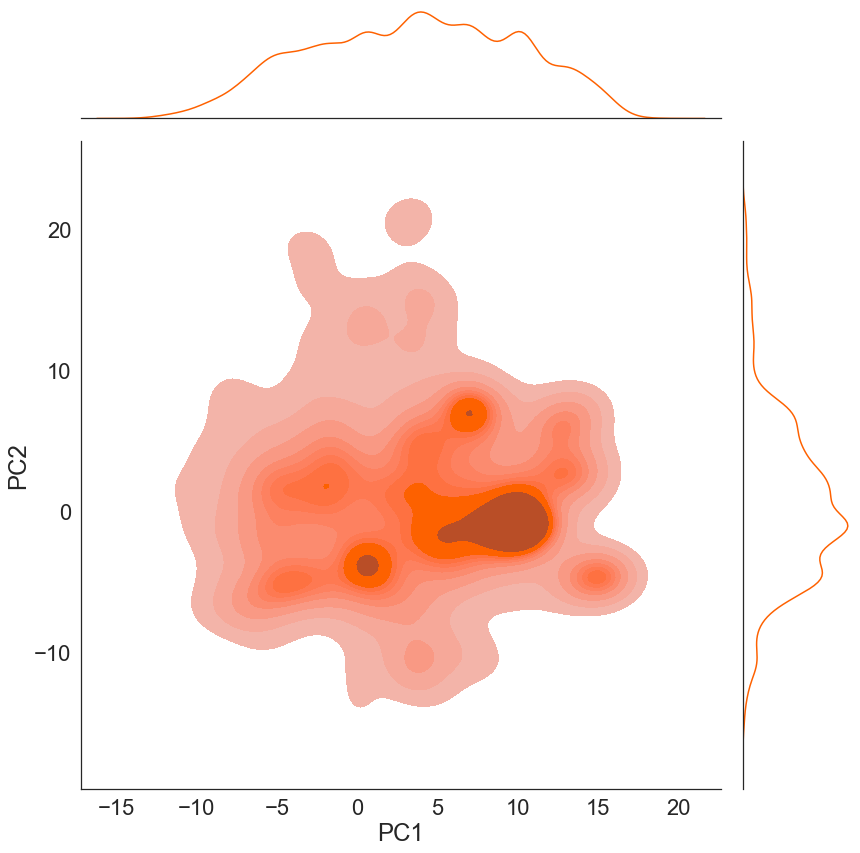

In [13]:
sns.set(font_scale=2,style = "white",rc={"axes.spines.right": False, "axes.spines.top":False})
fig = sns.jointplot(pcaPoints[0][:int(len(pcaPoints[0])/3)],pcaPoints[1][:int(len(pcaPoints[0])/3)],kind = 'kde',shade = True, color=colourScheme[0],xlabel = "PC1",height = 12)

fig.set_axis_labels('PC1','PC2')


Text(0, 0.5, 'PC2')

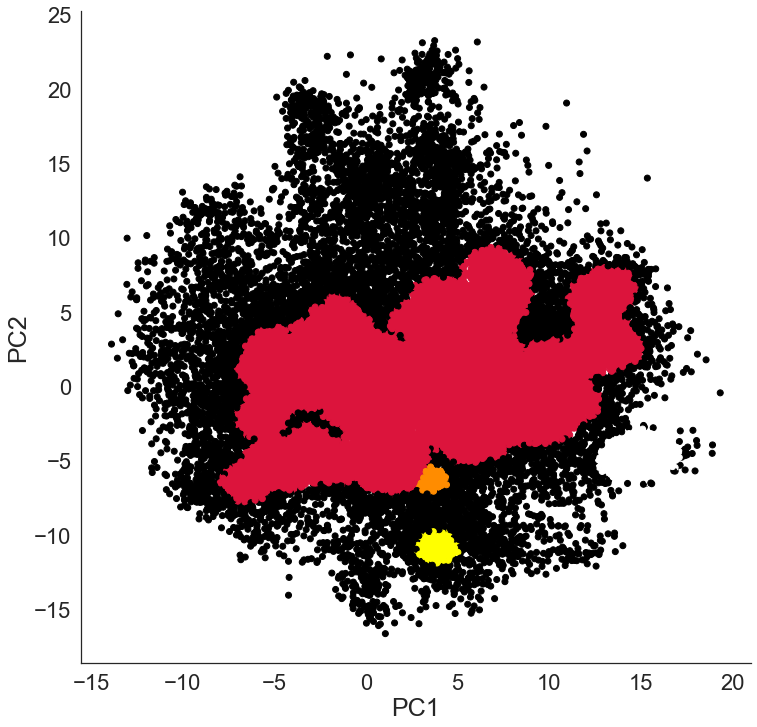

In [14]:
from sklearn.cluster import DBSCAN

db1 = DBSCAN(eps=.7,min_samples = 125).fit(array(transformed_dists[0]).reshape(-1,2))


colordict = {
    -1:"black",
    0:"crimson",
    1:"darkorange",
    2:"yellow",
    3:"white"
    
}
clusterColours=[]
for i in range(len(db1.labels_)):
    
    clusterColours.append(colordict[db1.labels_[i]])



figure(figsize = (12,12))
scatter(array(transformed_dists[0]).reshape(-1,2).T[0],array(transformed_dists[0]).reshape(-1,2).T[1],c = clusterColours)


xlabel("PC1",fontsize = 25)
ylabel("PC2",fontsize = 25)

In [15]:



    
    
        
        
        
complexRef = mda.Universe("../complex/1/3_npt/protein_cluster_center_ff.gro")
hivseq = complexRef.select_atoms("resid 1:232").residues.resnames[:231]


complexUs=[]
for j in range(5):
    tu = mda.Universe("../complex/"+str(j+1)+"/3_npt/protein_cluster_center_ff.gro","../complex/"+str(j+1)+"/3_npt/protein_cluster_center_skip100.xtc")

    complexUs.append(tu)
    
complexTRIM=[]
complexTRIM_strings=[]
for i in range(len(complexUs)):
    complexTRIM.append(complexUs[i].select_atoms("protein and resid 289:20000"))
    complexTRIM_strings.append("protein and resid 289:20000")
    
    
    
complex_v1s=[]
complex_v1strings=[]
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for j in range(len(complexUs)):
    complex_v1s.append(complexUs[j].select_atoms("protein and "+combinedLoopString))
    complex_v1strings.append("protein and "+combinedLoopString)   
    
complex_dists = getPairwiseDists([complexUs],[complex_v1s],[complex_v1strings],stride = 1,EQPOINT=0)[0]


In [16]:
complex_scaled_dists = (copy(complex_dists) - mean_final)/scale_final
complex_transformed_dists = []
for i in range(len(complex_scaled_dists)):

        
    complex_transformed_dists.append(myPCA.transform(complex_scaled_dists[i]))

In [21]:
##style.use("ggplot")
#figure(figsize = (25,25))
##for i in range(len(pcaPoints.T)):
##    scatter(pcaPoints.T[i][0],pcaPoints.T[i][1],color = pca_colours[i],alpha = 0.1)#,color = mycolors[i])#,label = structureList[i][3:])
#
#
#figure(figsize = (20,20))
##subplot(2,2,1)
#scatter(*pcaPoints,color = pca_colours,alpha = 0.2)
#legend_elements = [Line2D([0], [0], marker='o', color=colourScheme[0], label="Rhesus"),
#                       Line2D([0], [0], marker='o', color=colourScheme[1], label="WildType"),
#                       Line2D([0], [0], marker='o', color=colourScheme[2], label="Mutant")]
#legend(handles = legend_elements,loc='best',fontsize = 30)
#ylabel("PC2",fontsize = 30)
#ylim(-50,50)
#xlim(-50,50)
#
##subplot(2,2,2)
#scatter(*array(complex_transformed_dists).reshape(2,-1),alpha = 0.2,color = "grey")
#ylabel("PC2",fontsize = 30)
#ylim(-50,50)
#xlim(-50,50)
#

In [18]:
len(complex_dists[0])

501

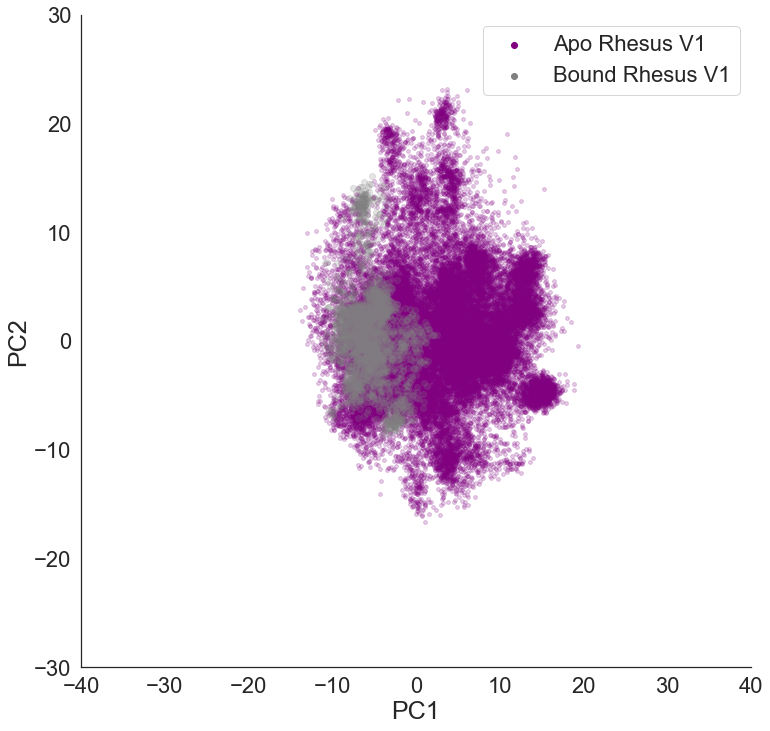

In [19]:
figure(figsize = (12,12))
scatter(50,50,c = "purple",label = "Apo Rhesus V1")
scatter(50,50,c = "grey",label = "Bound Rhesus V1")
scatter(array(transformed_dists[0]).reshape(-1,2).T[0],array(transformed_dists[0]).reshape(-1,2).T[1],c = "purple",alpha = 0.2,s=15)
scatter(array(complex_transformed_dists).reshape(-1,2).T[0],array(complex_transformed_dists).reshape(-1,2).T[1],c = "grey",alpha = 0.2)


xlim(-40,40)
ylim(-30,30)


#title("V1")
xlabel("PC1",fontsize = 25)
ylabel("PC2",fontsize = 25)

legend()

In [20]:
len(complex_dists)

5